# Karachi AQI — Exploratory Data Analysis

This notebook walks through the backfilled hourly dataset before training. Run `python run_pipeline.py backfill --days 365` first so `data/backfill.csv` is available.

Charts are saved under `notebooks/visuals/` (current pipeline figures only; stale files from older runs are removed automatically).

In [20]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")
%matplotlib inline

ROOT = Path("..").resolve()
VISUALS = ROOT / "notebooks" / "visuals"
DATA = ROOT / "data" / "backfill.csv"
VISUALS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT))

from src.features.build_features import (
    get_feature_columns,
    get_target_columns,
    prepare_training_frame,
    feature_columns_from_df,
    TARGET_COL,
)

with open(ROOT / "config" / "settings.yaml") as f:
    CFG = yaml.safe_load(f)

TRAIN_FRAC = CFG["data"].get("train_test_split", 0.8)
AQI_BANDS = [
    (50, "Good"),
    (100, "Moderate"),
    (150, "USG"),
    (200, "Unhealthy"),
    (300, "Very Unhealthy"),
]

# Only these figures belong to the current pipeline; anything else is removed on run.
CANONICAL_VISUALS = {
    "01_iqr_capping.png",
    "02_missingness.png",
    "04_aqi_timeseries.png",
    "05_aqi_distribution.png",
    "06_hourly_monthly_pattern.png",
    "07_correlation.png",
    "08_target_distribution.png",
    "10_train_test_split.png",
    "11_feature_target_assoc.png",
}

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "font.size": 10})

for stale in VISUALS.glob("*.png"):
    if stale.name not in CANONICAL_VISUALS:
        stale.unlink()
        print(f"Removed stale visual → {stale.name}")

def savefig(name: str):
    if name not in CANONICAL_VISUALS:
        raise ValueError(f"Unknown visual '{name}'. Allowed: {sorted(CANONICAL_VISUALS)}")
    path = VISUALS / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

## 1. Loading the data and checking quality

Before any plots, I check whether the hourly file is complete enough to trust for modeling.

In [21]:
df = pd.read_csv(DATA, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Period: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

expected = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing_hours = expected.difference(df["timestamp"])
print(f"Missing hourly slots: {len(missing_hours)} ({100 * len(missing_hours) / len(expected):.1f}% of full timeline)")

miss = (df.isnull().mean() * 100).sort_values(ascending=False)
print("\nMissing % (top columns):")
print(miss.head(12).round(2).to_string())

display(df.head(3))

DATASET OVERVIEW
Rows: 8,782  |  Columns: 28
Period: 2025-06-04 02:00:00 → 2026-06-04 23:00:00
Duplicate timestamps: 0
Missing hourly slots: 0 (0.0% of full timeline)

Missing % (top columns):
pm2_5                               0.0
pm10                                0.0
is_rush_hour                        0.0
pm_ratio                            0.0
aqi_change_rate                     0.0
pm10_rolling_std_72h                0.0
pm2_5_rolling_std_72h               0.0
pm10_rolling_mean_36h               0.0
carbon_monoxide_rolling_mean_36h    0.0
pm2_5_rolling_mean_36h              0.0
wind_v                              0.0
wind_u                              0.0


,pm2_5,pm10,carbon_monoxide,carbon_dioxide,no2,sulphur_dioxide,o3,dust,uv_index,aqi_us,...,wind_v,pm2_5_rolling_mean_36h,carbon_monoxide_rolling_mean_36h,pm10_rolling_mean_36h,pm2_5_rolling_std_72h,pm10_rolling_std_72h,aqi_change_rate,pm_ratio,is_rush_hour,precip_likelihood
0,31.7,75.0,178.0,449,8.2,8.0,71.0,72.0,0.0,89,...,7.951650,32.450,229.00,67.05,0.494975,3.606245,0.0,0.422667,0,4368
1,31.1,77.3,161.0,448,7.6,8.1,69.0,76.0,0.0,89,...,8.273149,32.200,212.00,69.70,0.556776,5.250714,0.0,0.402329,0,2700
2,30.2,77.1,154.0,448,7.6,8.5,66.0,78.0,0.0,90,...,7.763414,31.925,199.25,71.60,0.713559,5.728874,1.0,0.391699,0,2581


**Summary:** The backfill covers hourly rows across the date range above with no duplicate timestamps. Gaps on the calendar are expected when the API does not return every day; the important part is that the rows we have are usable and that pollutant and weather columns are filled in.

## 2. How the data is cleaned before training

Quick reference to the same steps the Python pipelines apply.

In [22]:
pipeline_steps = pd.DataFrame([
    ("Ingest", "Hourly air quality + weather merged on timestamp (full pollutant panel: PM2.5, PM10, CO, CO2, NO2, SO2, O3, dust, UV + weather)"),
    ("Clean", "Short gaps filled via forward-fill → linear interpolation → backward-fill"),
    ("IQR capping", "Outliers capped at 1.5×IQR bounds per column (bounded/circular cols skipped)"),
    ("Features", "Cyclic hour_sin, wind U/V from speed+direction, 36h rolling means, 72h rolling stds, AQI change rate, PM2.5/PM10 ratio, is_rush_hour, precip_likelihood"),
    ("Target", "Next-hour US AQI: aqi_us.shift(-1) — single-step prediction"),
    ("Split", f"Time-ordered {int(TRAIN_FRAC*100):.0f}/{int((1-TRAIN_FRAC)*100):.0f} train/test split"),
    ("Models", "RandomForest, GradientBoosting, XGBoost, SVR, Ridge — best by R² retrained on full data"),
    ("Forecast", "Multi-day outlooks produced by iterative (recursive) one-hour-ahead prediction (96 steps)"),
], columns=["Stage", "What happens"])
display(pipeline_steps)

feature_cols = get_feature_columns()
target_col = get_target_columns()[0]
print(f"\nThe model uses {len(feature_cols)} canonical input columns.")
print(f"Target: {target_col}  (next-hour AQI, used for iterative multi-day forecasting)")

,Stage,What happens
0,Ingest,Hourly air quality + weather merged on timesta...
1,Clean,Short gaps filled via forward-fill → linear in...
2,IQR capping,Outliers capped at 1.5×IQR bounds per column (...
3,Features,"Cyclic hour_sin, wind U/V from speed+direction..."
4,Target,Next-hour US AQI: aqi_us.shift(-1) — single-st...
5,Split,Time-ordered 80/19 train/test split
6,Models,"RandomForest, GradientBoosting, XGBoost, SVR, ..."
7,Forecast,Multi-day outlooks produced by iterative (recu...



The model uses 25 canonical input columns.
Target: target  (next-hour AQI, used for iterative multi-day forecasting)


**Summary:** Open-Meteo hourly data is cleaned, IQR-capped, and engineered into model features. The trainer predicts next-hour AQI (`target`); multi-day dashboard horizons are produced later by iterative one-hour-ahead forecasting.

## 3. IQR outlier capping

Raw sensor readings occasionally contain spikes. We cap each numeric column at the 1.5×IQR bounds (except bounded or circular columns like humidity, cloud cover, and wind direction).

Values clipped in 'pm2_5': 0 (0.0%)
Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\01_iqr_capping.png


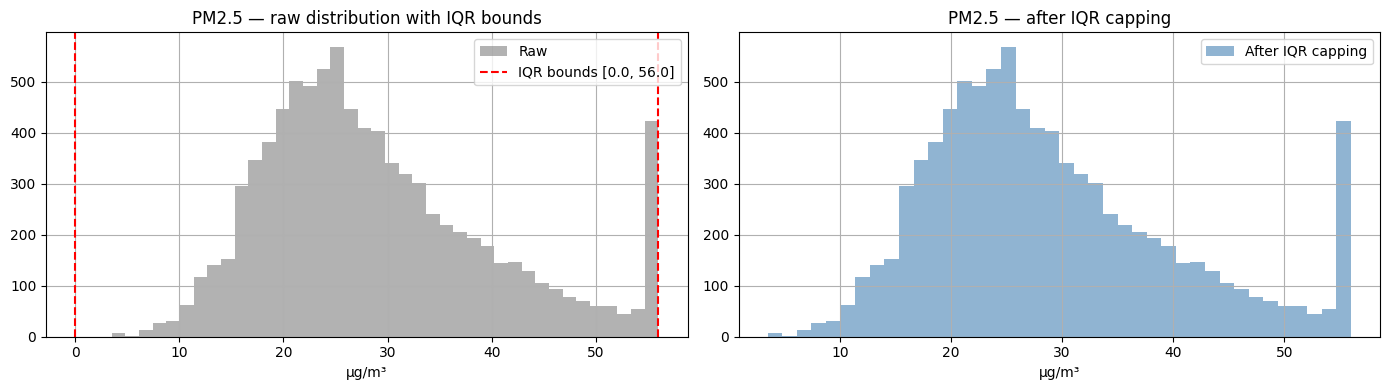

In [23]:
from src.features.build_features import iqr_data

# Compare PM2.5 distributions before and after IQR capping
demo_col = "pm2_5"
df_capped = iqr_data(df[[demo_col]].copy())

q1 = df[demo_col].quantile(0.25)
q3 = df[demo_col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
n_clipped = ((df[demo_col] < lower) | (df[demo_col] > upper)).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df[demo_col].dropna(), bins=40, alpha=0.6, color="gray", label="Raw")
axes[0].axvline(lower, color="red", lw=1.5, linestyle="--", label=f"IQR bounds [{lower:.1f}, {upper:.1f}]")
axes[0].axvline(upper, color="red", lw=1.5, linestyle="--")
axes[0].set_title("PM2.5 — raw distribution with IQR bounds")
axes[0].set_xlabel("µg/m³")
axes[0].legend()

axes[1].hist(df_capped[demo_col].dropna(), bins=40, alpha=0.6, color="steelblue", label="After IQR capping")
axes[1].set_title("PM2.5 — after IQR capping")
axes[1].set_xlabel("µg/m³")
axes[1].legend()

print(f"Values clipped in '{demo_col}': {n_clipped} ({100*n_clipped/len(df):.1f}%)")
savefig("01_iqr_capping.png")
plt.show()

**Summary:** IQR capping removes extreme sensor spikes. Only a small fraction of values are affected; the bulk of the distribution is unchanged, preserving realistic pollution signal while preventing outliers from distorting the model.

## 4. Missing values in raw data

Completeness of pollutant and weather columns before feature engineering.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\02_missingness.png


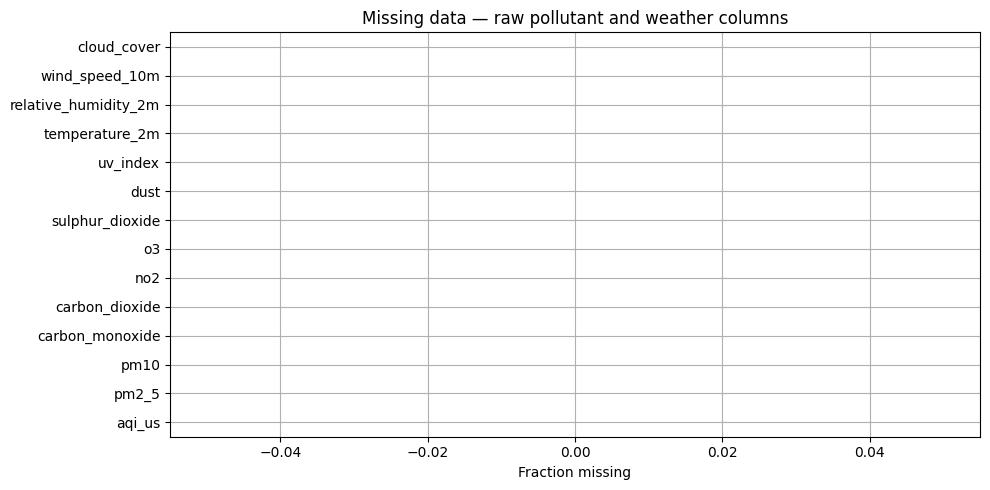

Rows with all features present (after pipeline): 8,782 / 8,782


In [24]:
key_cols = [
    "aqi_us", "pm2_5", "pm10", "carbon_monoxide", "carbon_dioxide",
    "no2", "o3", "sulphur_dioxide", "dust", "uv_index",
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "cloud_cover",
]
key_cols = [c for c in key_cols if c in df.columns]
miss_key = df[key_cols].isnull().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
miss_key.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("Fraction missing")
ax.set_title("Missing data — raw pollutant and weather columns")
savefig("02_missingness.png")
plt.show()

train_ready = prepare_training_frame(df)
print(f"Rows with all features present (after pipeline): {len(train_ready):,} / {len(df):,}")

**Summary:** Pollutant and weather fields are mostly complete in this CSV. The count printed above is rows with all engineered features present after the pipeline runs; the next-hour target is added later in section 5.

## 5. Data preparation and 80/20 train/test split

Full pipeline applied (clean → IQR cap → engineer features → next-hour target), then time-ordered 80/20 split — mirrors the production training pipeline exactly.

In [25]:
full_train = prepare_training_frame(df)

# Add next-hour AQI target (mirrors _build_target in sklearn_trainer.py)
full_train[TARGET_COL] = full_train["aqi_us"].shift(-1)
full_train = full_train.dropna(subset=[TARGET_COL]).reset_index(drop=True)

# Update feature_cols from the actual engineered frame
feature_cols = feature_columns_from_df(full_train)

# Time-ordered 80/20 split (identical to production training_pipeline)
n_train = int(TRAIN_FRAC * len(full_train))
train = full_train.iloc[:n_train].copy()
test  = full_train.iloc[n_train:].copy()

print(f"Full dataset : {len(full_train):,} rows  ({full_train['timestamp'].min().date()} → {full_train['timestamp'].max().date()})")
print(f"Train set    : {len(train):,} rows  ({train['timestamp'].min().date()} → {train['timestamp'].max().date()})")
print(f"Test set     : {len(test):,} rows   ({test['timestamp'].min().date()} → {test['timestamp'].max().date()})")
print(f"Target       : '{TARGET_COL}' — next-hour US AQI (shift -1)")
print(f"Feature count: {len(feature_cols)}")

Full dataset : 8,781 rows  (2025-06-04 → 2026-06-04)
Train set    : 7,024 rows  (2025-06-04 → 2026-03-23)
Test set     : 1,757 rows   (2026-03-23 → 2026-06-04)
Target       : 'target' — next-hour US AQI (shift -1)
Feature count: 25


**Summary:** The full pipeline (clean → IQR cap → feature engineering → next-hour target) is applied once to the entire series before splitting, ensuring rolling-window statistics are computed correctly across the full history. The 80/20 time-ordered split matches the production training pipeline — no future data leaks into the training set.

## 6. AQI over time

Long view of air quality across the backfill period.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\04_aqi_timeseries.png


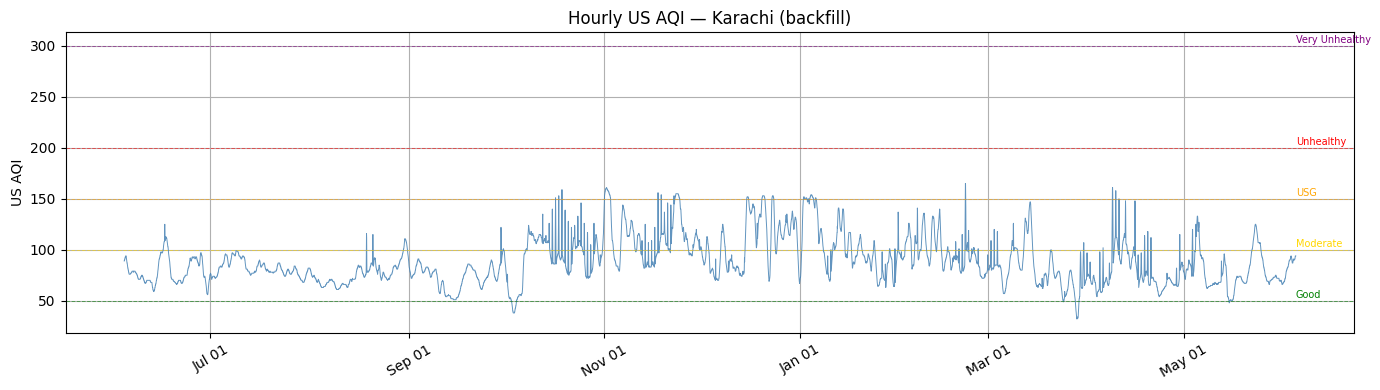

Median AQI: 84


In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["timestamp"], df["aqi_us"], lw=0.7, color="steelblue", alpha=0.85)
colors = ["green", "gold", "orange", "red", "purple", "maroon"]
for (thr, label), color in zip(AQI_BANDS, colors):
    ax.axhline(thr, ls="--", lw=0.7, alpha=0.55, color=color)
    ax.text(df["timestamp"].max(), thr + 3, label, fontsize=7, color=color)
ax.set_title("Hourly US AQI — Karachi (backfill)")
ax.set_ylabel("US AQI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
savefig("04_aqi_timeseries.png")
plt.show()

print(f"Median AQI: {df['aqi_us'].median():.0f}")

**Summary:** AQI moves up and down over the backfill window rather than staying flat. Many hours sit in Moderate or worse bands, so there is enough variation for the model to learn from.

## 7. How often each AQI category appears

Distribution of hourly readings against standard EPA bands.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\05_aqi_distribution.png


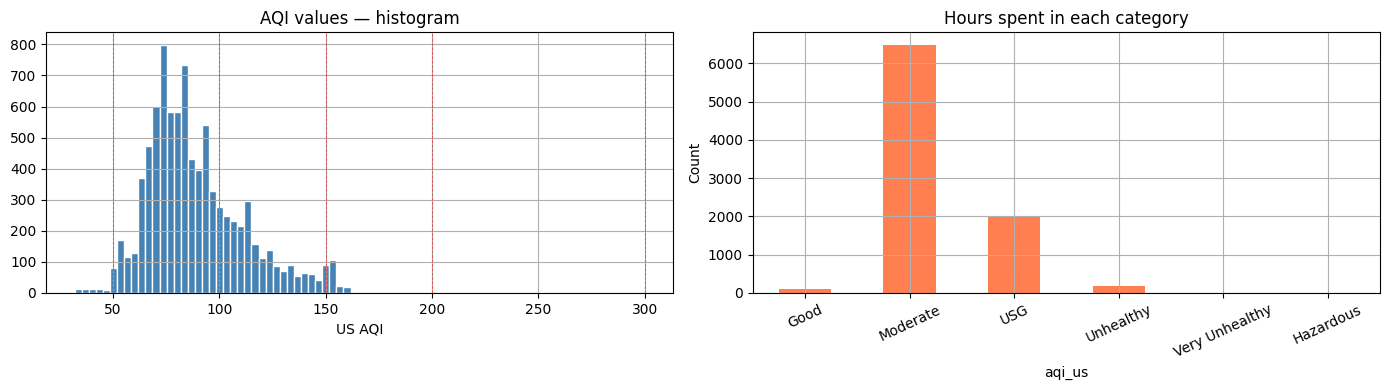

aqi_us
Good                98.0
Moderate          6490.0
USG               2004.0
Unhealthy          190.0
Very Unhealthy       0.0
Hazardous            0.0


In [27]:
def aqi_category(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "USG"
    if aqi <= 200: return "Unhealthy"
    if aqi <= 300: return "Very Unhealthy"
    return "Hazardous"

cats = df["aqi_us"].apply(aqi_category)
order = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]
cat_counts = cats.value_counts().reindex(order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["aqi_us"].dropna(), bins=40, color="steelblue", edgecolor="white")
for thr, _ in AQI_BANDS:
    axes[0].axvline(thr, color="red", ls="--", lw=0.6, alpha=0.6)
axes[0].set_title("AQI values — histogram")
axes[0].set_xlabel("US AQI")

cat_counts.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Hours spent in each category")
axes[1].set_ylabel("Count")
plt.xticks(rotation=25)
savefig("05_aqi_distribution.png")
plt.show()

print(cat_counts.to_string())

**Summary:** Most hours fall in Moderate or higher categories. Karachi does not spend most of its time in the Good band, which matches what we expect from local air quality.

## 8. Patterns by hour and month

Diurnal cycle and seasonal tendency in the backfill window.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\06_hourly_monthly_pattern.png


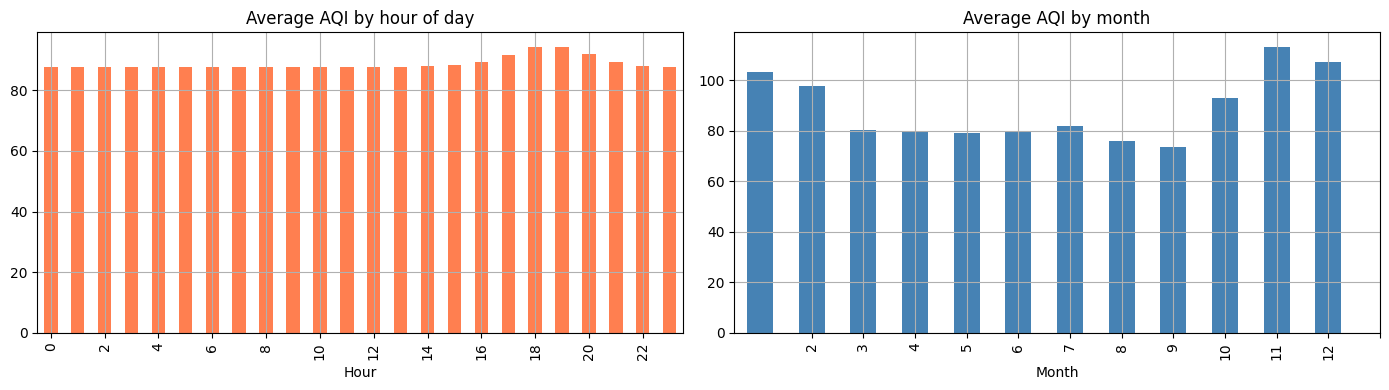

In [28]:
hour = df["timestamp"].dt.hour
month = df["timestamp"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby(hour)["aqi_us"].mean().plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Average AQI by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_xticks(range(0, 24, 2))

df.groupby(month)["aqi_us"].mean().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Average AQI by month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1, 13))
savefig("06_hourly_monthly_pattern.png")
plt.show()

**Summary:** AQI is not uniform across the day or across months. Some hours and cooler months look worse on average, which is why cyclic time features are included in the model.

## 9. Correlations between inputs

Which columns move together—and which would duplicate each other in a linear model.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\07_correlation.png


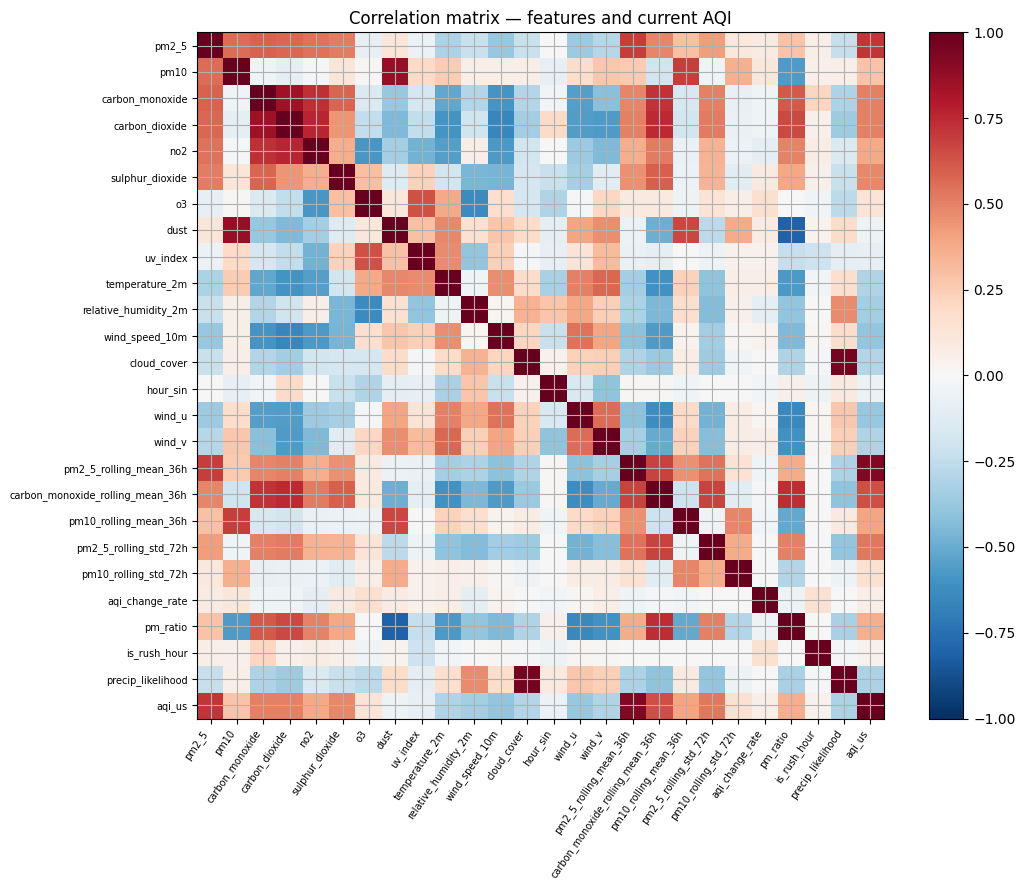

In [29]:
corr_cols = [c for c in feature_cols + ["aqi_us"] if c in full_train.columns]
corr = full_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=7)
ax.set_yticklabels(corr_cols, fontsize=7)
ax.set_title("Correlation matrix — features and current AQI")
savefig("07_correlation.png")
plt.show()

**Summary:** Pollutants and their rolling statistics cluster with AQI because they track the same air-mass signal. Weather columns are more separate, which is why wind and humidity add complementary information beyond pollution levels alone.

## 10. Next-hour target distribution

The model predicts a single next-hour AQI value (`target = aqi_us.shift(-1)`). Multi-day forecasts are produced later by iterative (recursive) one-step-ahead prediction.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\08_target_distribution.png


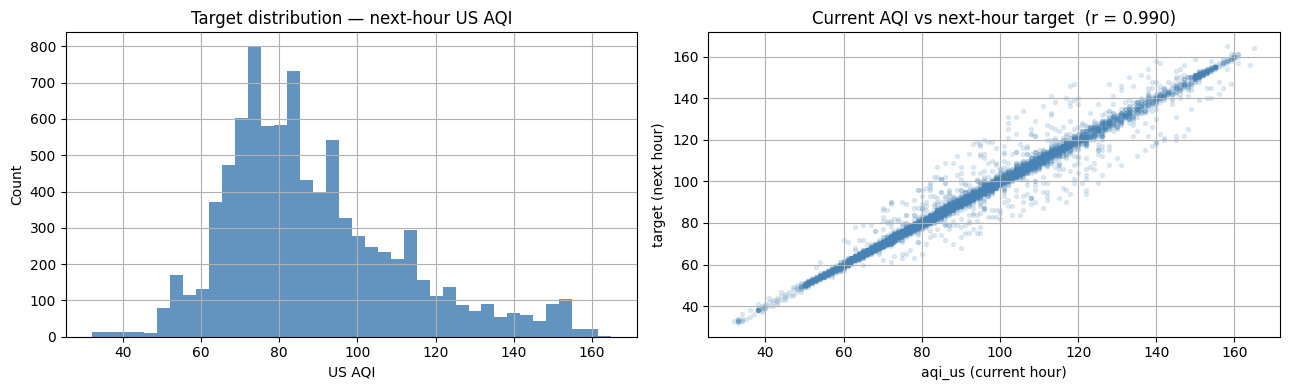

Target mean  : 88.7
Target median: 84.0
Target std   : 23.0
Persistence correlation (current -> next hour): 0.9905


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: target (next-hour AQI) distribution
full_train[TARGET_COL].dropna().hist(bins=40, ax=axes[0], color="steelblue", alpha=0.85)
axes[0].set_title("Target distribution — next-hour US AQI")
axes[0].set_xlabel("US AQI")
axes[0].set_ylabel("Count")

# Right: current AQI vs next-hour AQI scatter (persistence baseline)
sub = full_train[["aqi_us", TARGET_COL]].dropna()
axes[1].scatter(sub["aqi_us"], sub[TARGET_COL], alpha=0.15, s=8, color="steelblue")
r_val = sub["aqi_us"].corr(sub[TARGET_COL])
axes[1].set_title(f"Current AQI vs next-hour target  (r = {r_val:.3f})")
axes[1].set_xlabel("aqi_us (current hour)")
axes[1].set_ylabel("target (next hour)")

plt.tight_layout()
savefig("08_target_distribution.png")
plt.show()

print(f"Target mean  : {full_train[TARGET_COL].mean():.1f}")
print(f"Target median: {full_train[TARGET_COL].median():.1f}")
print(f"Target std   : {full_train[TARGET_COL].std():.1f}")
print(f"Persistence correlation (current -> next hour): {r_val:.4f}")

**Summary:** The next-hour AQI target is skewed toward moderate-to-poor air quality, matching the raw AQI distribution. The very high correlation between current and next-hour AQI confirms strong persistence — the model's job is to capture the residual variation around that persistence baseline. Multi-day outlooks are produced iteratively: predict +1h, feed the prediction back, repeat 96 times.

## 11. Train and test split

We hold out the most recent 20% of hours so the model is scored on future-like data, not random rows.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\10_train_test_split.png


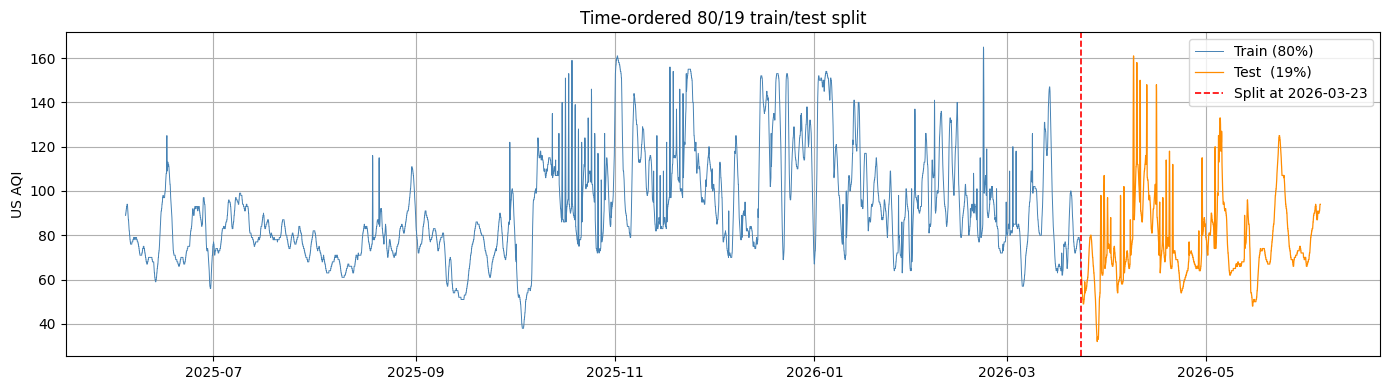

In [31]:
cutoff = train["timestamp"].max()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["timestamp"], train["aqi_us"], label=f"Train ({int(TRAIN_FRAC*100)}%)", color="steelblue", lw=0.7)
ax.plot(test["timestamp"],  test["aqi_us"],  label=f"Test  ({int((1-TRAIN_FRAC)*100)}%)", color="darkorange", lw=0.9)
ax.axvline(cutoff, color="red", ls="--", lw=1.2, label=f"Split at {cutoff.date()}")
ax.set_title(f"Time-ordered {int(TRAIN_FRAC*100)}/{int((1-TRAIN_FRAC)*100)} train/test split")
ax.set_ylabel("US AQI")
ax.legend()
savefig("10_train_test_split.png")
plt.show()

**Summary:** The oldest 80% of hours go to training; the most recent 20% form the test set. This time-ordered split prevents any leakage of future information into the model. After evaluation, the best-performing model is retrained on the full dataset before deployment.

## 12. Which features track the next-hour target best

Simple linear association—not final importance, but a sanity check.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\11_feature_target_assoc.png


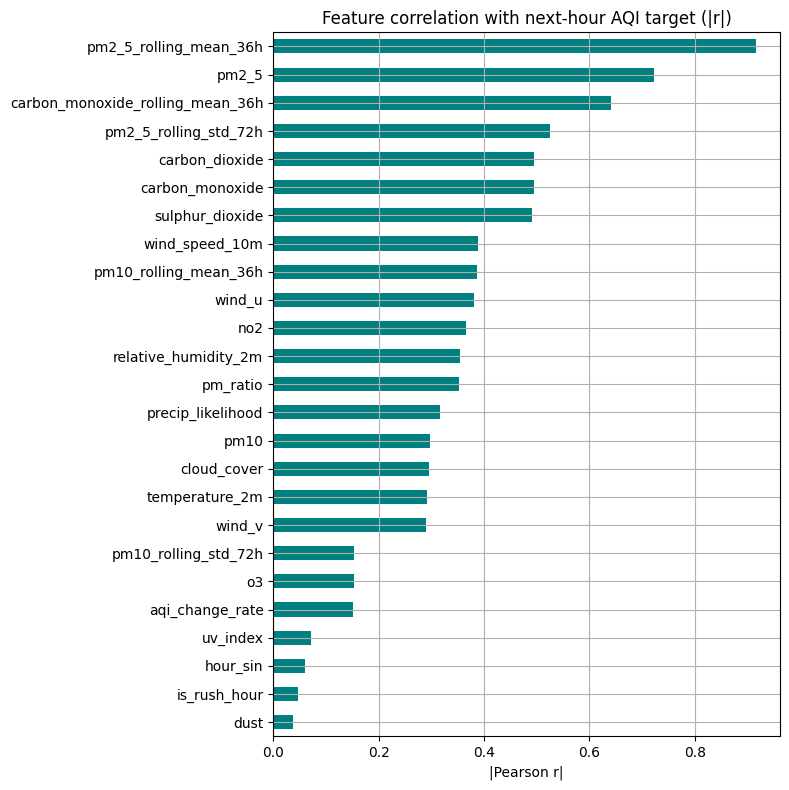

Top-5 strongest links to the next-hour AQI target:
carbon_dioxide                      0.494842
pm2_5_rolling_std_72h               0.525762
carbon_monoxide_rolling_mean_36h    0.641411
pm2_5                               0.722131
pm2_5_rolling_mean_36h              0.915719


In [32]:
assoc = (
    full_train[feature_cols + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(8, max(5, len(assoc) // 3)))
assoc.plot(kind="barh", ax=ax, color="teal")
ax.set_title(f"Feature correlation with next-hour AQI target (|r|)")
ax.set_xlabel("|Pearson r|")
plt.tight_layout()
savefig("11_feature_target_assoc.png")
plt.show()

print("Top-5 strongest links to the next-hour AQI target:")
print(assoc.tail(5).to_string())

**Summary:** Rolling means and the current AQI value dominate the correlation with the next-hour target, confirming that recent air quality history is the strongest predictor. Weather columns (wind, humidity, temperature) act as secondary modifiers. This pattern justifies the 36-hour rolling means and AQI change-rate features as the most valuable engineered inputs.

## 13. Closing notes

This run writes exactly nine figures to `notebooks/visuals/`:

`01_iqr_capping.png`, `02_missingness.png`, `04_aqi_timeseries.png`, `05_aqi_distribution.png`, `06_hourly_monthly_pattern.png`, `07_correlation.png`, `08_target_distribution.png`, `10_train_test_split.png`, `11_feature_target_assoc.png`

Re-run the notebook after a new backfill if `data/backfill.csv` changes.

In [33]:
saved = [VISUALS / name for name in sorted(CANONICAL_VISUALS) if (VISUALS / name).exists()]
missing = sorted(CANONICAL_VISUALS - {p.name for p in saved})

print(f"{len(saved)} / {len(CANONICAL_VISUALS)} current pipeline figures in {VISUALS}:")
for p in saved:
    print(f"  - {p.name}")

if missing:
    print("\nNot generated this run (re-run cells above if needed):")
    for name in missing:
        print(f"  - {name}")

9 / 9 current pipeline figures in C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals:
  - 01_iqr_capping.png
  - 02_missingness.png
  - 04_aqi_timeseries.png
  - 05_aqi_distribution.png
  - 06_hourly_monthly_pattern.png
  - 07_correlation.png
  - 08_target_distribution.png
  - 10_train_test_split.png
  - 11_feature_target_assoc.png
